In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content')
from utils import *

In [ ]:
import os, random
from PIL import Image
import numpy as np
from torch.utils.data import Dataset, DataLoader,Subset
from torchvision import datasets, models, transforms
from torchvision.models import alexnet, resnet18, resnet34, resnet50, resnet101, resnet152
from torchvision.models import vgg11, VGG11_Weights, vgg11_bn, VGG11_BN_Weights, vgg13, VGG13_Weights, vgg13_bn, VGG13_BN_Weights
from torchvision.models import vgg16, VGG16_Weights, vgg16_bn, VGG16_BN_Weights, vgg19, VGG19_Weights, vgg19_bn, VGG19_BN_Weights
from torchvision.models import ResNet18_Weights, ResNet34_Weights, ResNet50_Weights, ResNet101_Weights, ResNet152_Weights, AlexNet_Weights
from tqdm import tqdm
from functools import partial
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim

### Fig. 3B reproduction: intrinsic dimension on ImageNet
* Loads a few ImageNet categories and samples images per category.
* Runs several pretrained ImageNet models (VGG / VGG-BN / ResNet18).
* Uses TwoNN and MLE estimators to compute layer-wise intrinsic dimension.
* Averages ID profiles across categories via `merged_over_categories`.

The output `merged_ID_all_category` is what we later feed to `plot_fig3b`.

In [ ]:
class PathListDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        dummy_label = 0
        return img, dummy_label

def merged_over_categories(results):

    """
    Average ID measures across multiple categories.

    """

    merged_result = {}
    model_names = results[0].keys()
    for model_name in model_names:
        depths = results[0][model_name]["depths"]
        twonn_per_cat = [res[model_name]["TwoNN"] for res in results]
        mle_per_cat = [res[model_name]["MLE"] for res in results]


        twonn_avg = np.array(twonn_per_cat, dtype=float).mean(axis=0).tolist()
        mle_avg = np.array(mle_per_cat, dtype=float).mean(axis=0).tolist()

        merged_result[model_name] = {
            "depths": depths,
            "TwoNN": twonn_avg,
            "MLE": mle_avg
        }

    return merged_result


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Pretrained CNN models, their depth definitions, and intrinsic dimension estimators ---
models = {
    "VGG19": vgg19(weights=VGG19_Weights.IMAGENET1K_V1),
    "VGG16": vgg16(weights=VGG16_Weights.IMAGENET1K_V1),
    "VGG13": vgg13(weights=VGG13_Weights.IMAGENET1K_V1),
    "VGG11": vgg11(weights=VGG11_Weights.IMAGENET1K_V1),
    "VGG19_BN": vgg19_bn(weights=VGG19_BN_Weights.IMAGENET1K_V1),
    "VGG16_BN": vgg16_bn(weights=VGG16_BN_Weights.IMAGENET1K_V1),
    "VGG13_BN": vgg13_bn(weights=VGG13_BN_Weights.IMAGENET1K_V1),
    "VGG11_BN": vgg11_bn(weights=VGG11_BN_Weights.IMAGENET1K_V1),
    "AlexNet": alexnet(weights=AlexNet_Weights.IMAGENET1K_V1),
    "ResNet152": resnet152(weights=ResNet152_Weights.IMAGENET1K_V1),
    "ResNet101": resnet101(weights=ResNet101_Weights.IMAGENET1K_V1),
    "ResNet50": resnet50(weights=ResNet50_Weights.IMAGENET1K_V1),
    "ResNet34": resnet34(weights=ResNet34_Weights.IMAGENET1K_V1),
    "ResNet18": resnet18(weights=ResNet18_Weights.IMAGENET1K_V1),
}

depth_fns = {
    "VGG19": getDepths,
    "VGG16": getDepths,
    "VGG13": getDepths,
    "VGG11": getDepths,
    "VGG19_BN": getDepths,
    "VGG16_BN": getDepths,
    "VGG13_BN": getDepths,
    "VGG11_BN": getDepths,
    "AlexNet": getDepths,
    "ResNet152": getResNetsDepths,
    "ResNet101": getResNetsDepths,
    "ResNet50": getResNetsDepths,
    "ResNet34": getResNetsDepths,
    "ResNet18": getResNetsDepths,
}

estimators = {"TwoNN":partial(repeat_compute,estimator=partial(twonn_id,device=device,batch=256)),
              "MLE":partial(repeat_compute,estimator=partial(mle_id,device=device,batch=256))
              }


# --- input preprocessing ---
data_transform = transforms.Compose([
        transforms.Resize( (224,224) , interpolation=2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


# --- ImageNet data source and selected categories  ---
src_dir = "/content/drive/MyDrive/imagenet_training_single_objs"
file_names = ["n01882714/0","n02086240/0","n02087394/0","n02094433/0","n02100583/0","n02100735/0","n02279972/0"]



ID_all_category = []
for i,name in enumerate(file_names):

    print(f"Category{i+1}/{len(file_names)}")
    file_name = os.path.join(src_dir,name)
    all_imgs = [os.path.join(file_name, f) for f in os.listdir(file_name) if f.endswith(".JPEG")]
    dataset = PathListDataset(all_imgs, transform=data_transform)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True,num_workers=2)

    id_for_one_category = compute_id_dynamics_across_models(models,
                                                            estimators,
                                                            dataloader,
                                                            depth_fns,
                                                            device,
                                                            pca_dim=False)
    ID_all_category.append(id_for_one_category)


merged_ID_all_category = merged_over_categories(ID_all_category)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 214MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 135MB/s]


Downloading: "https://download.pytorch.org/models/vgg13-19584684.pth" to /root/.cache/torch/hub/checkpoints/vgg13-19584684.pth


...

Models: 100%|██████████| 14/14 [07:44<00:00, 33.18s/it]


Category6/7


Models: 100%|██████████| 14/14 [05:48<00:00, 24.92s/it]


Category7/7


Models: 100%|██████████| 14/14 [05:40<00:00, 24.29s/it]


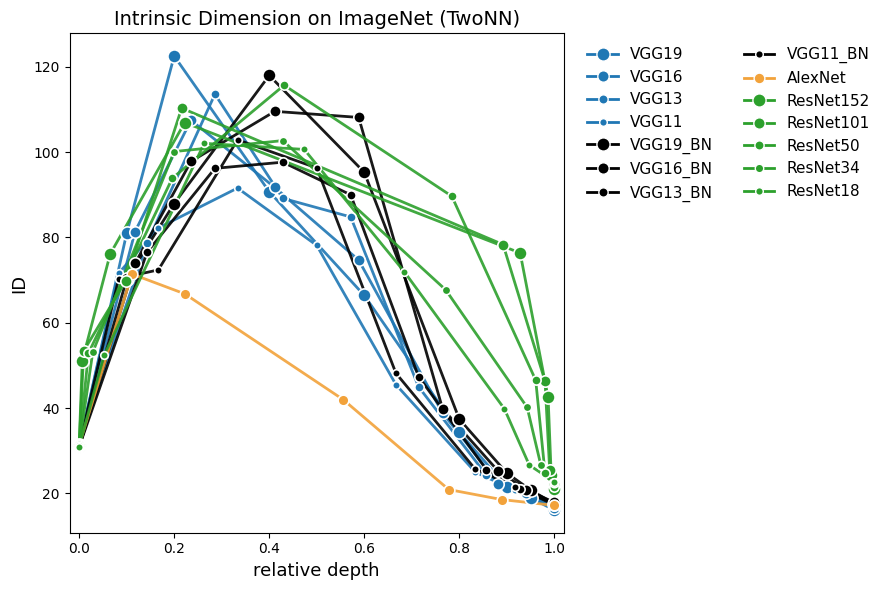

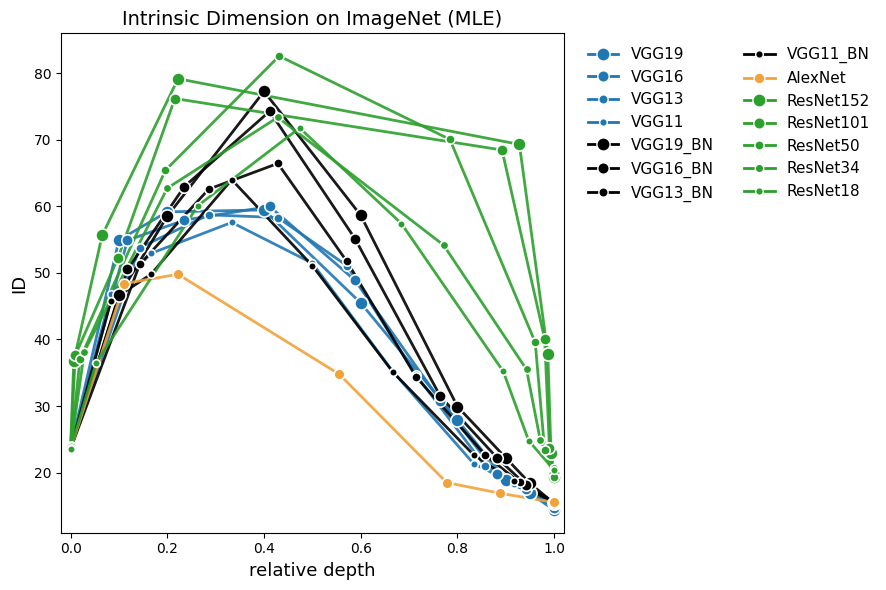

In [ ]:
for estimator in estimators:
    title = f"Intrinsic Dimension on ImageNet ({estimator})"
    plot_fig3b(merged_ID_all_category,estimator,title)

### Observation

We reproduced the experiments on various Convolutional Neural Network architectures (AlexNet, VGG, ResNet).The original figure used as a reference for reproduction is shown below. Consistent with the original findings, the Intrinsic Dimension exhibits a distinct "hunchback" profile across all models as a function of relative depth, matching the original results in both trend and magnitude.

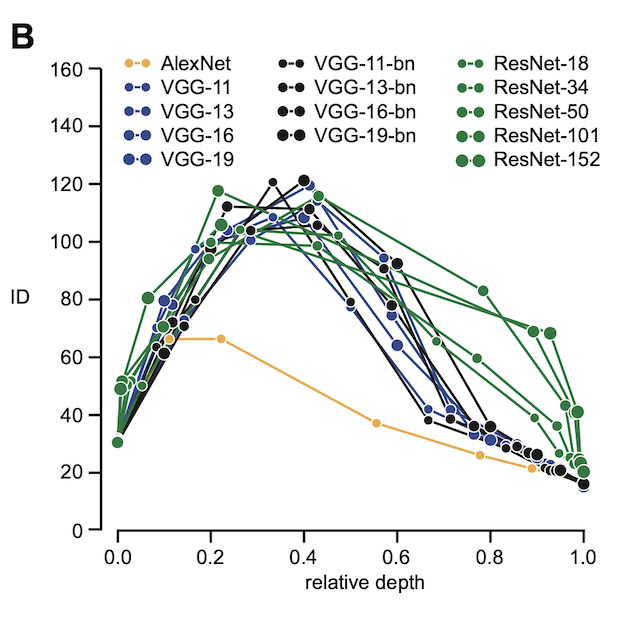

To further investigate estimation bias, we performed an additional analysis using the Maximum Likelihood Estimation (MLE) method. While the resulting curve retains the characteristic hunchback shape, the magnitude of the ID estimates differs significantly. Specifically, the peak ID under MLE is approximately 60～80, which is considerably lower than the value obtained via the 2NN estimator (~120). This observation aligns with our synthetic data benchmarks in Task 3, where MLE consistently yielded lower estimates than 2NN.

### Fig. 5C & Fig. 9 reproduction: training and ID dynamics on CIFAR-10

In this section we train VGG16, AlexNet and ResNet18 on CIFAR-10 and track the intrinsic dimension of their hidden representations. We use a small held-out subset of the test set to estimate layer-wise ID during training, and then reproduce the Fig. 5C and Fig. 9–style plots: ID / PC-ID / ED for trained vs. untrained networks, layer-wise ID over epochs, and the relationship between last-layer ID and test error.




In [ ]:
# CIFAR-10 data setup for training and intrinsic-dimension experiments.
# - Applies standard data augmentation to training set (crop + flip).
# - Creates a small image subset of the test set


transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train,
)

test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test,
)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)

num_samples = 500
indices = torch.randperm(len(test_set))[:num_samples]
small_test_set = Subset(test_set, indices)

small_test_loader = DataLoader(
    small_test_set,
    batch_size=100,
    shuffle=False,
    num_workers=2,
)


===== Running model: vgg16 =====


Training epochs: 100%|██████████| 20/20 [10:04<00:00, 30.24s/it]


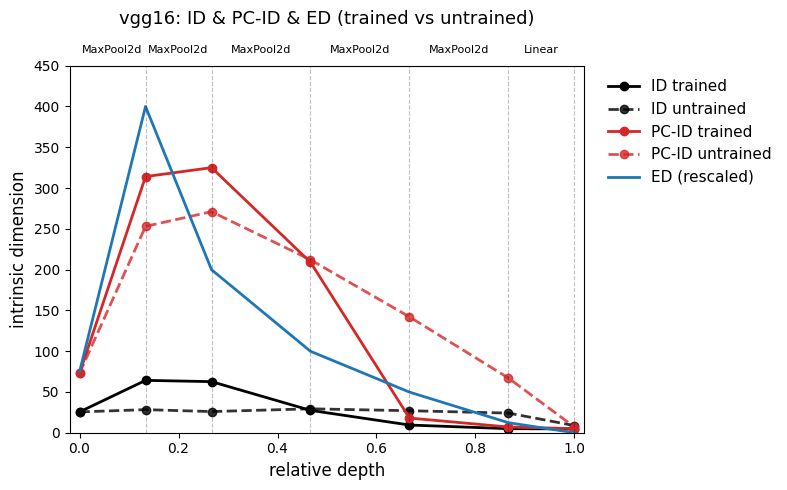

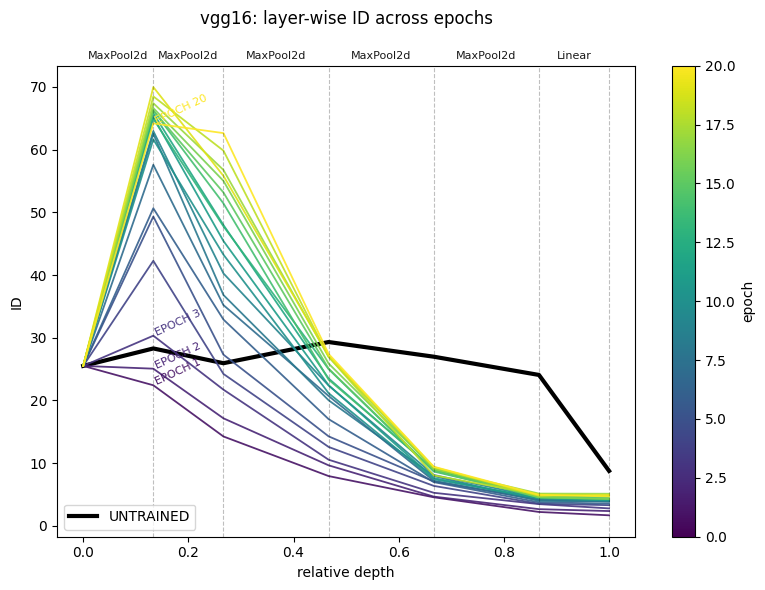

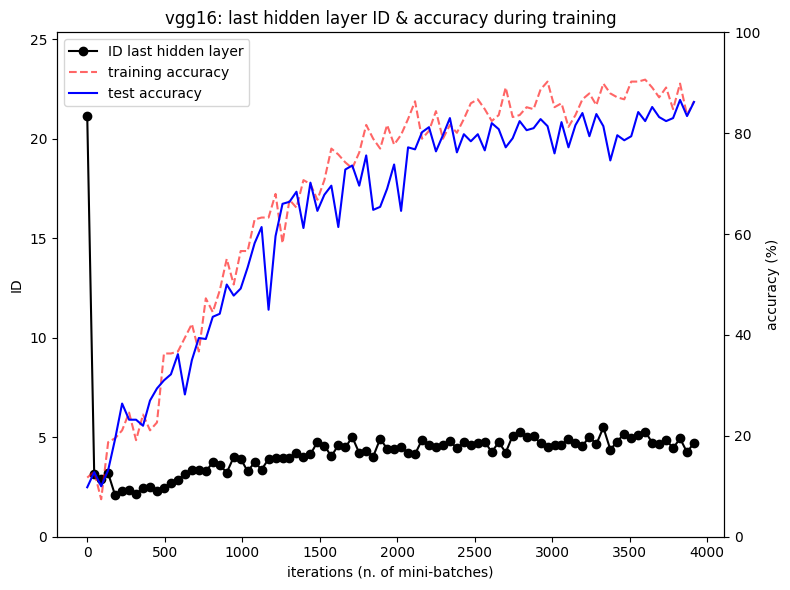

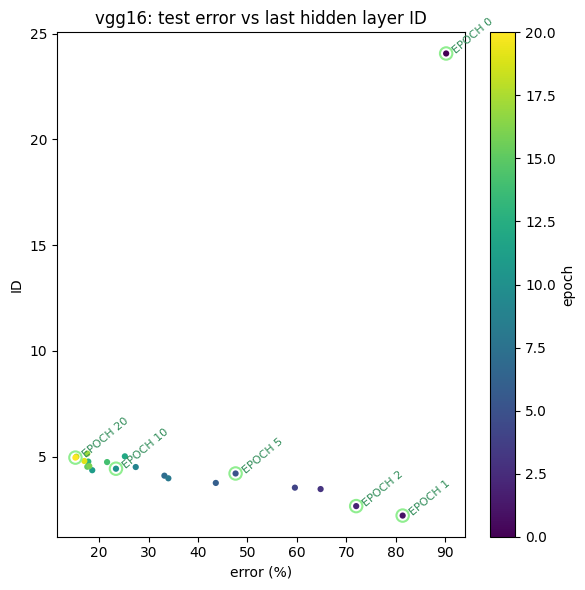


===== Running model: AlexNet =====


Training epochs: 100%|██████████| 20/20 [08:28<00:00, 25.41s/it]


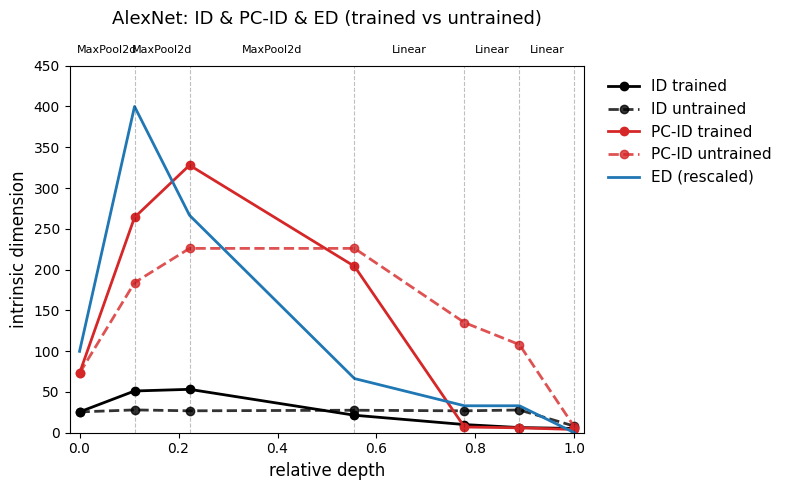

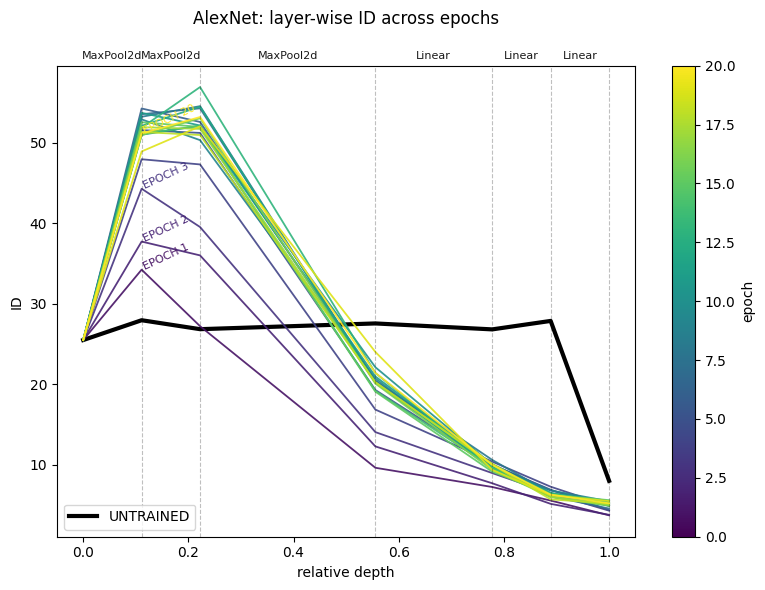

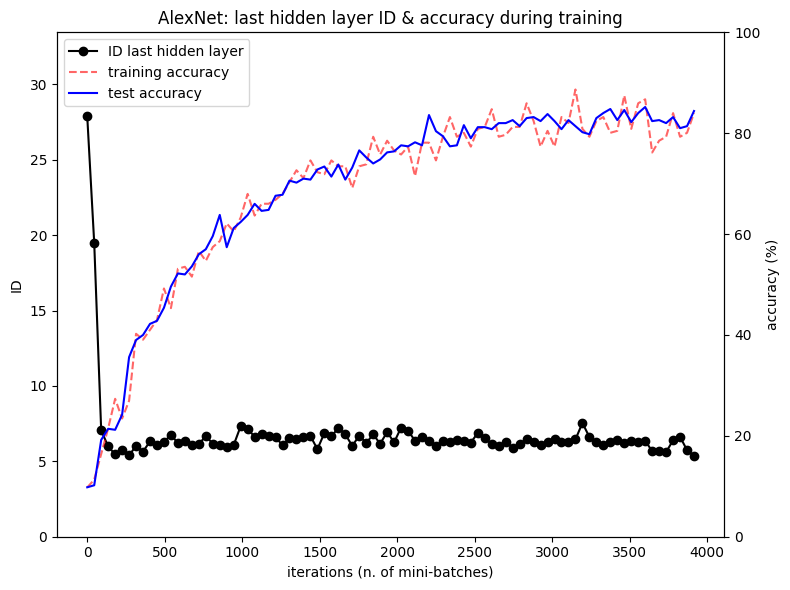

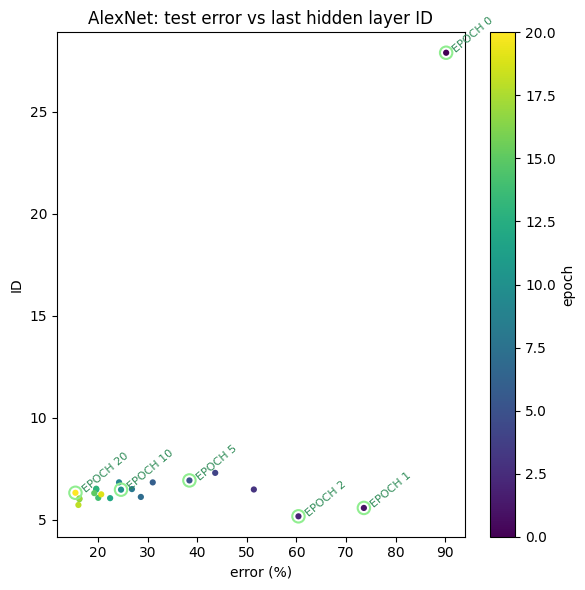


===== Running model: resnet18 =====


Training epochs: 100%|██████████| 20/20 [15:42<00:00, 47.12s/it]


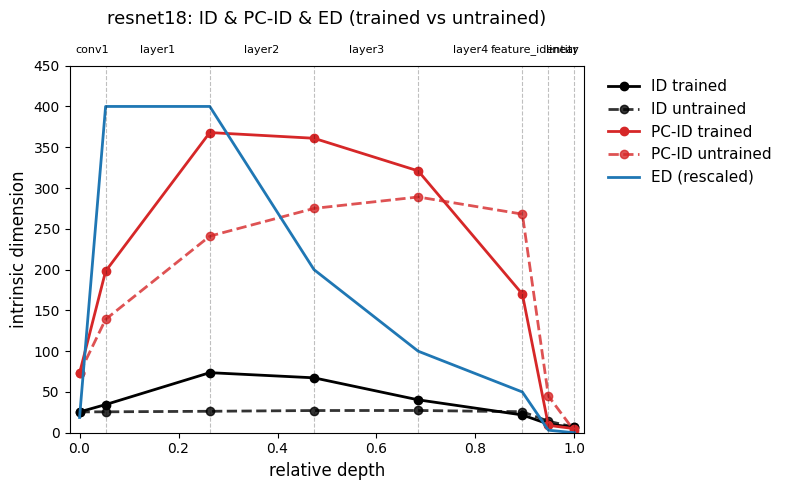

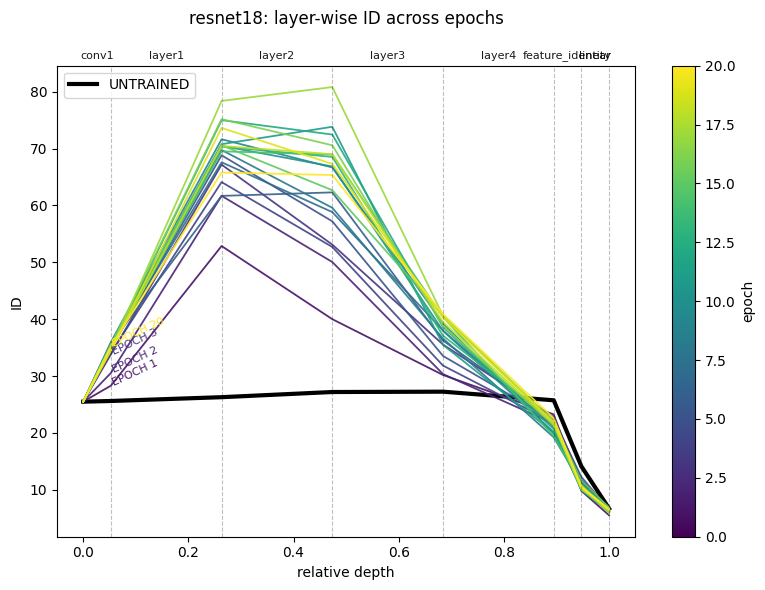

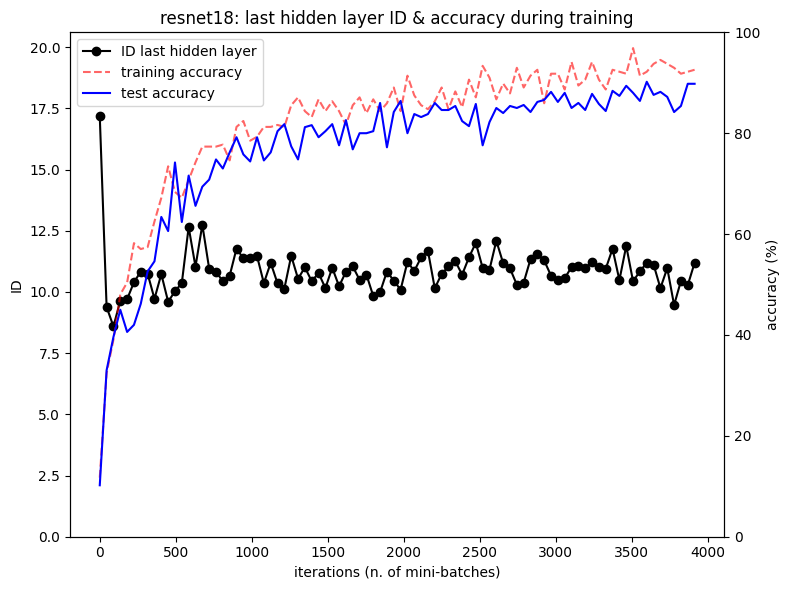

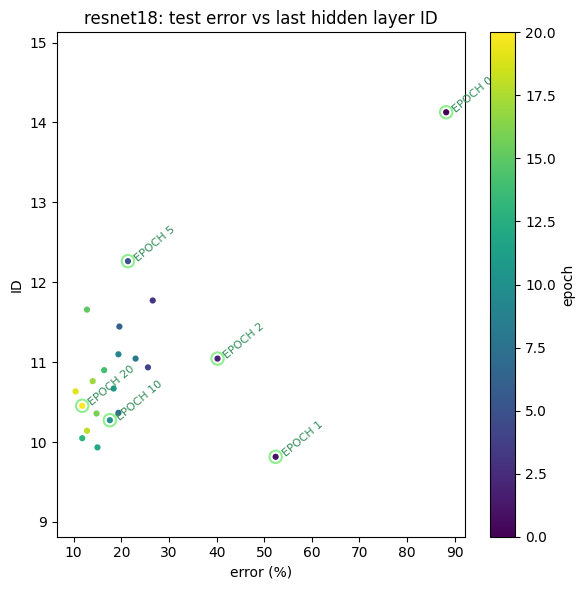

In [ ]:
epochs = 20
id_logging_interval = 45
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models_to_run = [
    ("vgg16",  VGG("VGG16")),
    ("AlexNet", AlexNet()),
    ("resnet18", ResNet18())
]
depth_fns = {"resnet18": getDepths_cifar_resnet,
             "vgg16":getDepths,
             "AlexNet":getDepths}


for model_name, net in models_to_run:

    print(f"\n===== Running model: {model_name} =====")

    model = {model_name: net}
    estimator = {"TwoNN":partial(twonn_id,device=device,batch=256)}
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        net.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4
    )
    total_steps = epochs * len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

    depths, result_per_batch, result_per_epoch, result_0_and_best_epoch,_ = \
        train_and_compute_id(
            epochs,
            model,
            train_loader,
            small_test_loader,
            estimator,
            criterion,
            optimizer,
            id_logging_interval,
            device,
            epoch_scheduler=scheduler,
            depth_fns=depth_fns
        )

    plot_fig5c(model_name, result_0_and_best_epoch, depths,400,title=f"{model_name}: ID & PC-ID & ED (trained vs untrained)",annotate=True)
    plot_fig9A(result_per_epoch, depths,title=f"{model_name}: layer-wise ID across epochs",annotate=True)
    plot_fig9B(result_per_batch,title=f"{model_name}: last hidden layer ID & accuracy during training")
    plot_fig9C(result_per_epoch,title=f"{model_name}: test error vs last hidden layer ID")



### Observation

A distinct "Hunchback" layer-wise profile is observed in all three models. The trained states (colored lines) clearly diverge from the untrained initializations (black lines), particularly in the early layers where the models learn to expand the manifold significantly more than their random initializations. Additionally, the Test Accuracy for all models stabilizes around 80% after training, and the trajectories in the Error vs. ID plots consistently show a trend moving towards the bottom-left.

However, the models differ fundamentally in how they reach their final state and the magnitude of their dimensionality: VGG16 and AlexNet exhibit heavier compression at last hidden layer, stabilizing at a final ID of approximately 5, whereas ResNet18 stabilizes at approximately 10 (roughly double the value of the former two), with a correspondingly higher intermediate layer peak than that of VGG16 and AlexNet.
